# Averaged error estimation

Calculate the averaged error with the RUS process and coherent error cancellation


k = 5,7,9

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Revised code for RUS error estimation

In [2]:
# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p
c = 1/15

# Fixed small physical error rate
p = 1e-5

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0
        # register for accumulated error
        PL_K_accumu = 0

        # start the wrapping process
        K = 1
        phi_try = phi
        while K < Kmax+1:
            # wrapping process
            # if phi_try > np.pi/8:
            #     phi_try = phi_try - np.pi/4
            # elif phi_try <= -np.pi/8:
            #     phi_try = phi_try + np.pi/4
            
            if phi_try > np.pi/8:
                phi_try = abs(phi_try - np.pi/4) 
            
            # dichotomy search for exact theta
            theta_try = solve_theta_scipy(phi_try, k)
            # theta_try_abs = abs(theta_try)

            # estimating PL_MK for the coherent error mitigation channel
            # Pid_suc = (1 - c*k*p)*(np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pid_suc = (np.cos(theta_try)**(2*k) + np.sin(theta_try)**(2*k))
            Pud_suc = c*k*p*(np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            PL_MK = Pud_suc / (Pid_suc + Pud_suc)

            # calculate the erroneous angle
            p_error = (np.cos(theta_try)**2)*(np.sin(theta_try)**2)* \
                    (np.cos(theta_try)**(2*k-4) + np.sin(theta_try)**(2*k-4))
            phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try)**(k-1)) \
                                        *np.cos(theta_try) )
            Delta_theta = abs(phi_try - phi_error)

            # error for the specific error mitigated channel                
            Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

            PL_K_accumu = PL_K_accumu + Error_KM

            PL = PL + ( 2**(-K) ) *PL_K_accumu

            # update variables
            K = K + 1
            phi_try = phi_try * 2

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p) )
        alpha_results[id_k, id_phi] = alpha

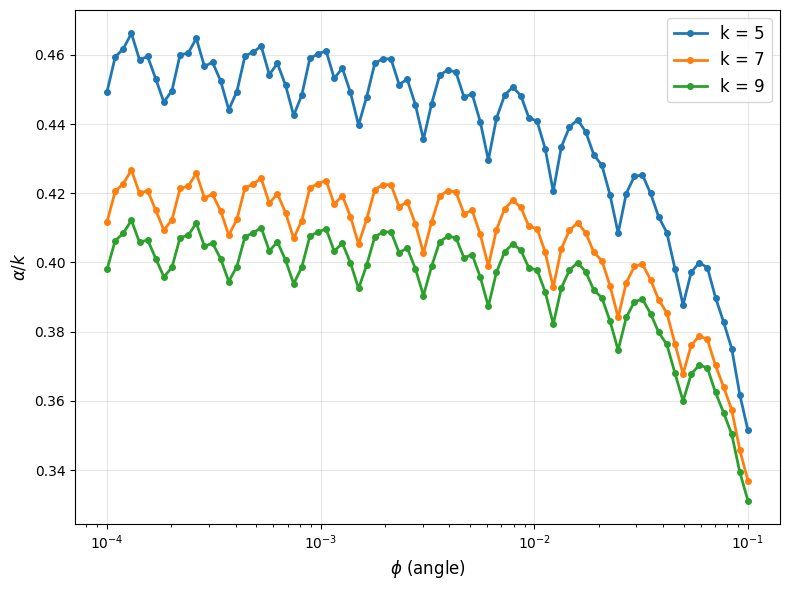

In [3]:
# Assuming you have:
# alpha_results: 2D numpy array with shape (3, N_phi)
# k_List = [5, 7, 9]
# phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each k value as a separate line
for id_k, k in enumerate(k_List):
    plt.plot(phi_List, alpha_results[id_k, :]/k, 
             label=f'k = {k}', 
             marker='o', markersize=4, linewidth=2)

# Customize the plot
plt.xscale('log')  # Since phi_List is logspaced
plt.xlabel(r'$\phi$ (angle)', fontsize=12)
plt.ylabel(r'$\alpha/k$', fontsize=12)
# plt.title(r'Dependence of \alpha on \phi for different k values', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()

### Former wrong code for RUS error estimation
wrong wrapping angle calculation

In [ ]:
### Wrong code: wrong wrapping method has been used

# number of rotation gates
k_List = [5,7,9]
N_k = 3

# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 80
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Pud1 upper bound overhead: Pud1 <= c k p
c = 1/15

# Fixed small physical error rate
p = 1e-4

# Truncation 
Kmax = 50

PL_results = np.zeros((N_k,N_phi))
alpha_results = np.zeros((N_k,N_phi))


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)
    

for id_k, k in enumerate(k_List):
    for id_phi, phi in enumerate(phi_List):
        # register for the averaged error
        PL = 0

        for K in range(1, Kmax+1):   # RUS trial number K
            # register for the overall error for a fixed trial number K
            PL_K = 0
            for M in range(1, K+1):     # Until K, we do coherent error mitigation for each M
                phi_try = (2**(M-1)) * phi
                
                # wrapping phi_try: wrap it to [-pi/8, pi/8)
                period = np.pi / 4
                phi_try_wrapped = ((phi_try + period/2) % period) - period/2
                
                # phi_try_wrapped = phi_try
                # while phi_try_wrapped > np.pi/8:
                #     phi_try_wrapped = np.abs(phi_try_wrapped - np.pi/4)

                # dichotomy search for exact theta
                theta_try = solve_theta_scipy(phi_try_wrapped, k)
                theta_try_abs = abs(theta_try)

                # approximate calculation of theta
                # if phi_try_wrapped > 0:
                #     theta_try =  phi_try_wrapped**(1/k)
                # else:
                #     theta_try = - abs(phi_try_wrapped)**(1/k)
                # if np.isnan(theta_try):
                #     print(f"Error: theta is NaN when phi = {phi_try_wrapped}")
                #     raise ValueError(f"theta is NaN when phi = {phi_try_wrapped}")
                # theta_try_abs = abs(theta_try)

                # Pud1_U = c*k*p

                # estimating PL_MK for the coherent error mitigation channel
                # ??? problematic??
                Pid_suc = (1 - c*k*p)*(np.cos(theta_try_abs)**(2*k) + np.sin(theta_try_abs)**(2*k))
                Pud_suc = c*k*p*(np.cos(theta_try_abs)**2)*(np.sin(theta_try_abs)**2)* \
                        (np.cos(theta_try_abs)**(2*k-4) + np.sin(theta_try_abs)**(2*k-4))
                PL_MK = Pud_suc / (Pid_suc + Pud_suc)

                # calculate the erroneous angle
                p_error = (np.cos(theta_try_abs)**2)*(np.sin(theta_try_abs)**2)* \
                        (np.cos(theta_try_abs)**(2*k-4) + np.sin(theta_try_abs)**(2*k-4))
                phi_error = - np.arcsin( ( 1/(np.sqrt(p_error)) )*(np.sin(theta_try_abs)**(k-1)) \
                                          *np.cos(theta_try_abs) )
                Delta_theta = abs(phi_try_wrapped) + abs(phi_error)

                # error for the specific error mitigated channel                
                Error_KM = 2 * PL_MK * (np.sin(Delta_theta)**2)

                PL_K = PL_K + Error_KM
            
            PL = PL + ( 2**(-K) ) * PL_K

        PL_results[id_k, id_phi] = PL
        alpha = PL/( np.abs(phi)*(p) )
        alpha_results[id_k, id_phi] = alpha

KeyboardInterrupt: 

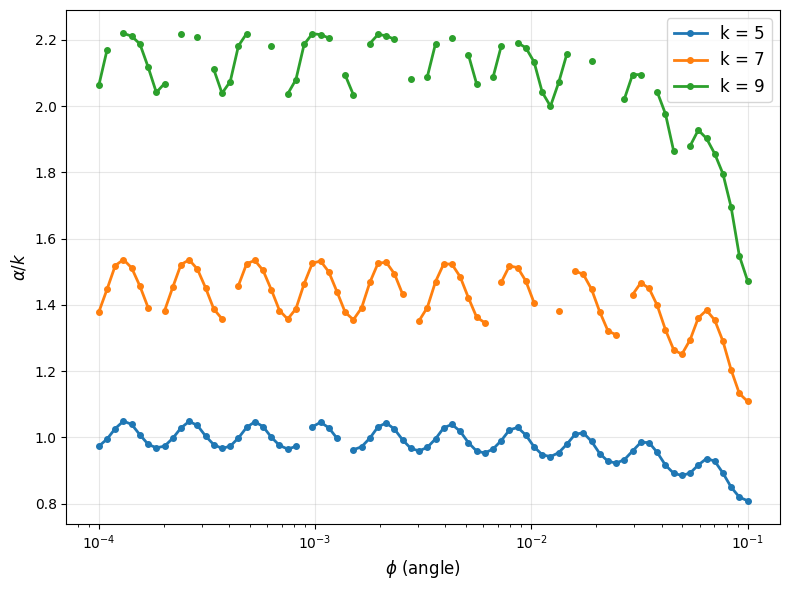

In [ ]:
# Assuming you have:
# alpha_results: 2D numpy array with shape (3, N_phi)
# k_List = [5, 7, 9]
# phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

# Create the plot
plt.figure(figsize=(8, 6))

# Plot each k value as a separate line
for id_k, k in enumerate(k_List):
    plt.plot(phi_List, alpha_results[id_k, :]/k, 
             label=f'k = {k}', 
             marker='o', markersize=4, linewidth=2)

# Customize the plot
plt.xscale('log')  # Since phi_List is logspaced
plt.xlabel(r'$\phi$ (angle)', fontsize=12)
plt.ylabel(r'$\alpha/k$', fontsize=12)
# plt.title(r'Dependence of \alpha on \phi for different k values', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Optional: Improve layout
plt.tight_layout()

# Show the plot
plt.show()

### test the dichotomy function

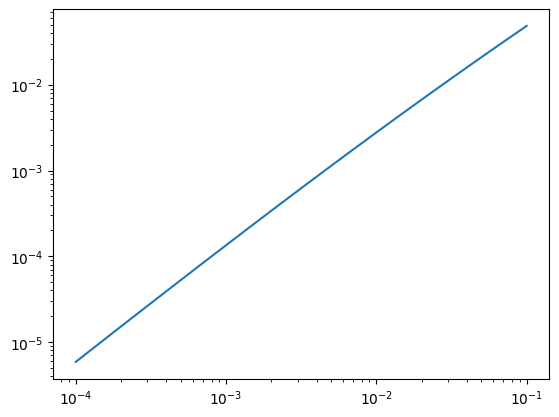

In [ ]:
# target rotation angle
phi_min = 1e-4
phi_max = 1e-1
N_phi = 60
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

theta_list = np.zeros(N_phi)
Delta_list = np.zeros(N_phi)

k = 5


def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    
    Parameters:
    - phi: float, between 0 and pi/10
    - k: float, exponent in the equation
    - delta: float, desired accuracy (default 1e-7)
    
    Returns:
    - theta: float, solution in radians between 0 and pi/4
    """
    a = -np.pi / 4
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        numerator = sin_theta ** k
        p_ideal = (sin_theta ** (2 * k)) + (cos_theta ** (2 * k))
        return (numerator / p_ideal) - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        raise ValueError("Function may not have a root in [-pi/4, pi/4]")
    
    while (b - a) >= delta:
        c = (a + b) / 2
        fc = f(c)
        
        if fc == 0.0:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
    
    return (a + b) / 2



for id_phi, phi in enumerate(phi_List):
    theta_try = solve_theta(phi, k)
    # theta_try =  phi**(1/k)
    
    p_ideal = np.sin(theta_try)**(2*k) + np.cos(theta_try)**(2*k)
    phi_try = np.arcsin( (np.sin(theta_try)**k)/np.sqrt( p_ideal ) )

    Delta_list[id_phi] = abs(phi_try - phi)

plt.loglog(phi_List, Delta_list)

phi=1.00e-04, theta=3.450078e-01, Delta=4.31e-15
phi=1.12e-04, theta=3.491690e-01, Delta=1.83e-15
phi=1.26e-04, theta=3.533719e-01, Delta=7.48e-15
phi=1.42e-04, theta=3.576166e-01, Delta=8.63e-15
phi=1.60e-04, theta=3.619031e-01, Delta=4.09e-15


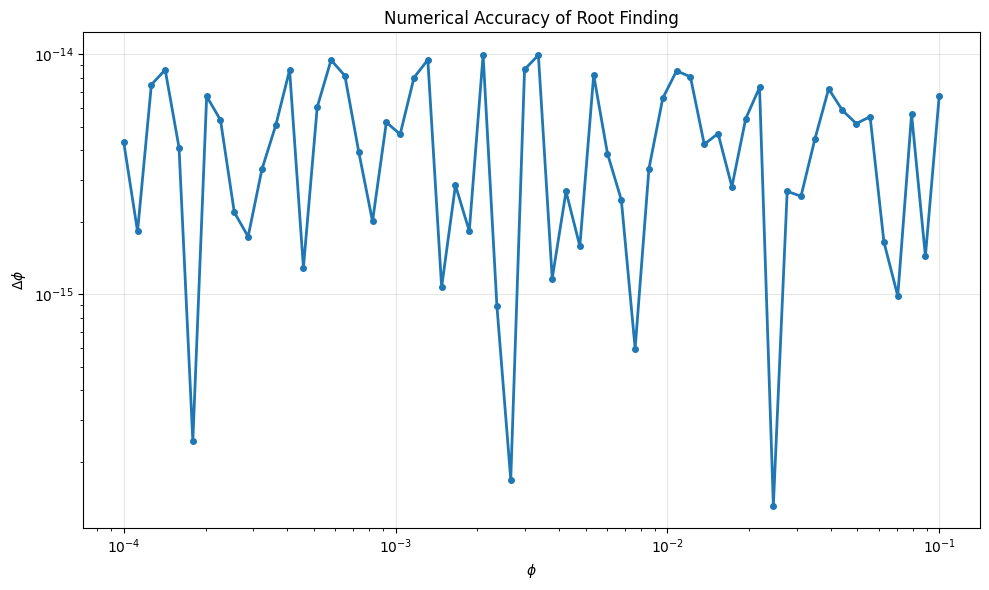

Max error: 9.95e-15
Mean error: 4.58e-15


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
phi_min = 1e-4
phi_max = 1e-1
N_phi = 60
phi_List = np.logspace(np.log10(phi_min), np.log10(phi_max), num=N_phi)

theta_list = np.zeros(N_phi)
Delta_list = np.zeros(N_phi)
k = 9

def solve_theta(phi, k, delta=1e-14):
    """
    Solve for theta using the dichotomy method given phi and k.
    Improved numerical stability version.
    """
    a = 1e-10  # Avoid exactly 0 for numerical stability
    b = np.pi / 4
    target = np.sin(phi)
    
    def f(theta):
        # Use logarithms for better numerical stability with large exponents
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # For small theta, use approximations to avoid precision loss
        if theta < 1e-6:
            # Taylor expansion for small theta
            numerator = theta**k
            p_ideal = theta**(2*k) + 1.0  # cos(theta)^(2k) ≈ 1 for small theta
        else:
            # Use logarithmic form for better numerical stability
            log_sin_k = k * np.log(sin_theta)
            log_cos_k = k * np.log(cos_theta)
            
            # For the ratio: numerator/denominator = exp(log_numerator - log_denominator)
            # But we need to handle the sum in denominator carefully
            numerator = np.exp(log_sin_k)
            term1 = np.exp(2 * log_sin_k)
            term2 = np.exp(2 * log_cos_k)
            
            # Handle potential overflow/underflow
            if term1 + term2 == 0:
                return -target
            p_ideal = term1 + term2
        
        ratio = numerator / np.sqrt(p_ideal)
        return ratio - target
    
    fa = f(a)
    fb = f(b)
    
    if fa * fb > 0:
        # Try to find a better initial bracket
        if abs(fa - target) < abs(fb - target):
            return a
        else:
            return b
    
    # Dichotomy method
    iterations = 0
    max_iter = 100
    while (b - a) >= delta and iterations < max_iter:
        c = (a + b) / 2
        fc = f(c)
        
        if abs(fc) < delta:
            return c
        
        if fa * fc < 0:
            b = c
            fb = fc
        else:
            a = c
            fa = fc
        iterations += 1
    
    return (a + b) / 2

# Alternative approach using scipy (more robust)
from scipy.optimize import root_scalar

def solve_theta_scipy(phi, k):
    """More robust solution using scipy's root finding"""
    target = np.sin(phi)
    
    def f(theta):
        sin_theta = np.sin(theta)
        cos_theta = np.cos(theta)
        
        # Use logarithmic form for stability
        log_sin = k * np.log(sin_theta)
        log_cos = k * np.log(cos_theta)
        
        numerator = np.exp(log_sin)
        denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
        
        return numerator / denominator - target
    
    try:
        result = root_scalar(f, bracket=[1e-10, np.pi/4], method='brentq', xtol=1e-12)
        return result.root
    except:
        # Fallback to dichotomy
        return solve_theta(phi, k, delta=1e-10)

# Test both methods
for id_phi, phi in enumerate(phi_List):
    # Use the improved method
    theta_try = solve_theta_scipy(phi, k)
    theta_list[id_phi] = theta_try
    
    # Calculate phi_try with improved numerical stability
    sin_theta = np.sin(theta_try)
    cos_theta = np.cos(theta_try)
    
    # Use logarithmic form
    log_sin = k * np.log(sin_theta)
    log_cos = k * np.log(cos_theta)
    
    numerator = np.exp(log_sin)
    denominator = np.sqrt(np.exp(2 * log_sin) + np.exp(2 * log_cos))
    phi_try = np.arcsin(numerator / denominator)
    
    Delta_list[id_phi] = abs(phi_try - phi)
    
    # Debug output for first few points
    if id_phi < 5:
        print(f"phi={phi:.2e}, theta={theta_try:.6e}, Delta={Delta_list[id_phi]:.2e}")

# Plot results
plt.figure(figsize=(10, 6))
plt.loglog(phi_List, Delta_list, 'o-', linewidth=2, markersize=4)
plt.xlabel(r'$\phi$')
plt.ylabel(r'$\Delta\phi$')
plt.title('Numerical Accuracy of Root Finding')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Check if results are reasonable
print(f"Max error: {np.max(Delta_list):.2e}")
print(f"Mean error: {np.mean(Delta_list):.2e}")